# Make prediction

In [30]:
import sys
import os

project_root = os.path.abspath("../")  # one level up from notebook/

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from pension_model.revamp_predictor import TimeSeriesPredictor

import pandas as pd

In [31]:
# Create a new predictor instance
new_predictor = TimeSeriesPredictor()

# Load the saved model
success = new_predictor.load_model("../models/production_model_v2")
if success:
    print("Model loaded successfully!")
    
    # Check what data is needed for predictions
    requirements = new_predictor.get_prediction_requirements()
    print("\nPrediction requirements:\n", requirements)

INFO:pension_model.revamp_predictor: Model loaded from ..\models\production_model_v2\model.pkl
INFO:pension_model.revamp_predictor: Preprocessing pipeline loaded from ..\models\production_model_v2\preprocessing_pipeline.pkl
INFO:pension_model.revamp_predictor:Metadata loaded from ..\models\production_model_v2\metadata.json
INFO:pension_model.revamp_predictor:Model loading completed successfully


Model loaded successfully!

Prediction requirements:
 {'required_base_columns': ['Annee', 'D_PIB', 'PROD', 'CHO', 'MI', 'FEC', 'ESP_F', 'ESP_H', 'PIB_VAL', 'PRELEV_REF', 'CONTRIB_REF', 'PIB_VOL'], 'max_lag_required': 2, 'minimum_rows_needed': 6, 'feature_engineering_applied': {'lag_periods': [1, 2], 'rolling_windows': [3, 6]}, 'total_features_created_and_selected': 15}


# Feature selected in best model

In [32]:
new_predictor.feature_names

Index(['PROD', 'PIB_VAL', 'PRELEV_REF', 'PIB_VOL', 'PROD_lag_1', 'PROD_lag_2',
       'PIB_VAL_lag_1', 'PIB_VOL_lag_1', 'PIB_VOL_lag_2', 'PROD_roll_mean_3',
       'PROD_roll_mean_6', 'PIB_VAL_roll_mean_3', 'PRELEV_REF_roll_mean_3',
       'PIB_VOL_roll_mean_3', 'PIB_VOL_roll_mean_6'],
      dtype='object')

## Import data

In [33]:
dtypes = {
    "Annee": "int64",
    "D_PIB": "float64"
}

raw_df = pd.read_csv("../data/dataset_COR_norm.csv", index_col=False, dtype=dtypes)
raw_df = raw_df.loc[:, ~raw_df.columns.str.contains("^Unnamed")]

In [37]:
# Check if the length is a multiple of 69
n_years = 69
assert len(raw_df) % n_years == 0, "Data length must be a multiple of 69"

# Create dictionary of DataFrames
grouped_dfs = {
    f"group_{i}": raw_df.iloc[i*n_years:(i+1)*n_years].reset_index(drop=True)
    for i in range(len(raw_df) // n_years)
}

# Show the first group
print(grouped_dfs["group_3"])

    Annee     D_PIB     PROD    CHO      MI    FEC     ESP_F     ESP_H  \
0    2002  0.117761  0.02786  0.079   97000  1.881  21.40000  17.10000   
1    2003  0.118774  0.00614  0.085  102000  1.891  21.30000  17.10000   
2    2004  0.119571  0.01315  0.089  105128  1.915  22.10000  17.70000   
3    2005  0.121331  0.00955  0.089   92192  1.938  22.00000  17.70000   
4    2006  0.121535  0.02648  0.088  112141  1.997  22.40000  18.00000   
..    ...       ...      ...    ...     ...    ...       ...       ...   
64   2066  0.146584  0.00400  0.050   70000  1.800  26.41802  24.36323   
65   2067  0.147034  0.00400  0.050   70000  1.800  26.49499  24.46490   
66   2068  0.147479  0.00400  0.050   70000  1.800  26.57171  24.56578   
67   2069  0.147951  0.00400  0.050   70000  1.800  26.64818  24.66589   
68   2070  0.148541  0.00400  0.050   70000  1.800  26.72440  24.76522   

     PIB_VAL  PRELEV_REF  CONTRIB_REF   PIB_VOL  
0   1578.330        26.9          2.0  2003.664  
1   1622.31

In [38]:
new_data = grouped_dfs["group_3"]

In [39]:
new_data.head()

,Annee,D_PIB,PROD,CHO,MI,FEC,ESP_F,ESP_H,PIB_VAL,PRELEV_REF,CONTRIB_REF,PIB_VOL
0,2002,0.117761,0.02786,0.079,97000,1.881,21.4,17.1,1578.330,26.9,2.0,2003.664
1,2003,0.118774,0.00614,0.085,102000,1.891,21.3,17.1,1622.313,27.6,2.0,2023.056
2,2004,0.119571,0.01315,0.089,105128,1.915,22.1,17.7,1696.108,27.9,2.0,2081.082
3,2005,0.121331,0.00955,0.089,92192,1.938,22.0,17.7,1762.048,27.9,2.0,2120.384
4,2006,0.121535,0.02648,0.088,112141,1.997,22.4,18.0,1846.021,28.0,2.1,2177.933


In [40]:
new_data.tail()

,Annee,D_PIB,PROD,CHO,MI,FEC,ESP_F,ESP_H,PIB_VAL,PRELEV_REF,CONTRIB_REF,PIB_VOL
64,2066,0.146584,0.004,0.05,70000,1.8,26.41802,24.36323,7595.846,28.7,1.1,3252.258
65,2067,0.147034,0.004,0.05,70000,1.8,26.49499,24.46490,7748.095,28.7,1.0,3260.389
66,2068,0.147479,0.004,0.05,70000,1.8,26.57171,24.56578,7903.396,28.7,1.0,3268.540
67,2069,0.147951,0.004,0.05,70000,1.8,26.64818,24.66589,8060.201,28.7,1.0,3276.058
68,2070,0.148541,0.004,0.05,70000,1.8,26.72440,24.76522,8217.657,28.7,1.0,3282.610


# Stress PROD

In [41]:
new_data['PROD'] *= 1 # 1 no stress

In [42]:
new_data.head()

,Annee,D_PIB,PROD,CHO,MI,FEC,ESP_F,ESP_H,PIB_VAL,PRELEV_REF,CONTRIB_REF,PIB_VOL
0,2002,0.117761,0.02786,0.079,97000,1.881,21.4,17.1,1578.330,26.9,2.0,2003.664
1,2003,0.118774,0.00614,0.085,102000,1.891,21.3,17.1,1622.313,27.6,2.0,2023.056
2,2004,0.119571,0.01315,0.089,105128,1.915,22.1,17.7,1696.108,27.9,2.0,2081.082
3,2005,0.121331,0.00955,0.089,92192,1.938,22.0,17.7,1762.048,27.9,2.0,2120.384
4,2006,0.121535,0.02648,0.088,112141,1.997,22.4,18.0,1846.021,28.0,2.1,2177.933


 # Make predictions

In [43]:
predictions_multi = new_predictor.predict_new_data(new_data)

INFO:pension_model.revamp_predictor: Predicting on 69 samples
INFO:pension_model.revamp_predictor: Input data validation passed
INFO:pension_model.revamp_predictor: Predictions completed for 69 samples


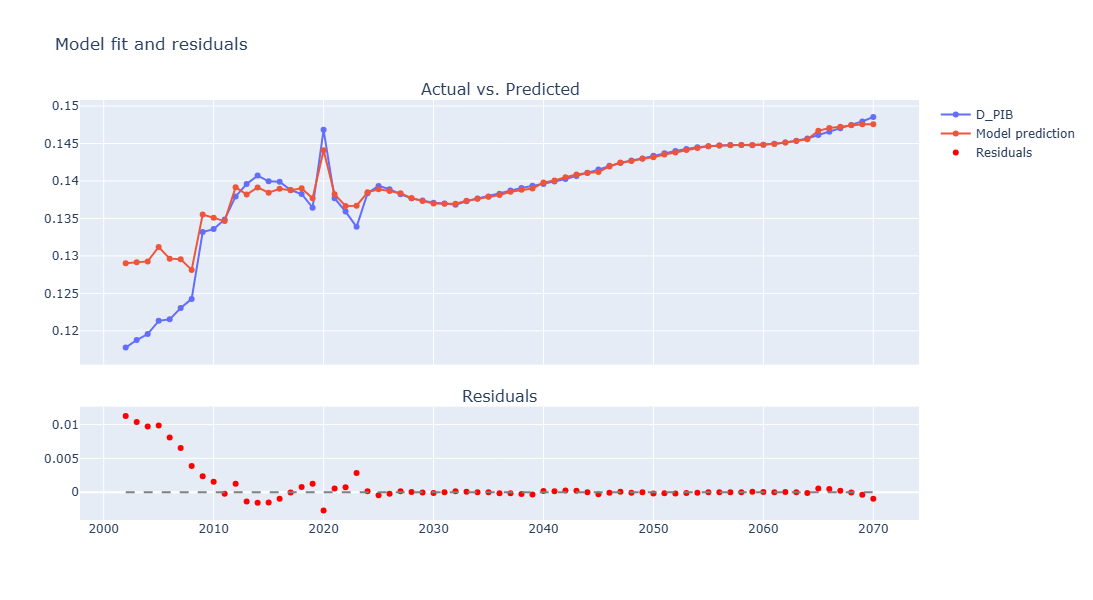

In [45]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = new_data.copy()

fig = go.Figure()

# Create subplots: 2 rows, shared x-axis
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.3],  # Top plot 70%, bottom 30%
    vertical_spacing=0.1,
    subplot_titles=("Actual vs. Predicted", "Residuals")
)

# First scatter
fig.add_trace(go.Scatter(
    x=df['Annee'],
    y=df['D_PIB'],
    mode='lines+markers',
    name='D_PIB'
), row=1, col=1)

# Add another scatter trace
fig.add_trace(go.Scatter(
    x=df['Annee'],
    y=predictions_multi,
    mode='lines+markers',
    name='Model prediction'
), row=1, col=1)

# --- Bottom Plot: Residuals ---
fig.add_trace(go.Scatter(
    x=df['Annee'], 
    y=predictions_multi - df['D_PIB'],
    mode='markers',
    name='Residuals',
    marker=dict(color='red')
), row=2, col=1)

# Add a zero line for residuals
fig.add_shape(type="line", x0=df['Annee'].min(), x1=df['Annee'].max(),
              y0=0, y1=0, line=dict(dash='dash', color='gray'),
              row=2, col=1)

# Layout adjustments
fig.update_layout(height=600, title="Model fit and residuals", showlegend=True)

fig.show()